# (노트) 신경망의 표현력

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [빅데이터분석]

### Import 

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt 

### graphviz setting

In [4]:
import graphviz

`-` graphviz가 설치안되어 있다면 아래와 같은 방법으로 설치하라. (2개 모두 실행할것)
```
!conda install -c conda-forge graphviz -y 
!pip install graphviz 
```

`-` 아래와 같이 하면 다이어그램을 쉽게 쓸 수 있다. 

In [5]:
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"' + s + '; }')

### 예제1: 선형모형

$y_i = w_0+ w_1 x_i + \epsilon_i \Longrightarrow  \hat{y}_i = \hat{w}_0 + \hat{w}_1 x_i $

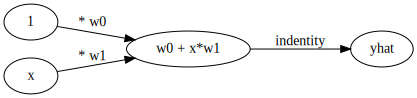

In [6]:
#collapse
gv(''' 
    "1" -> "w0 + x*w1"[label="* w0"]
    "x" -> "w0 + x*w1" [label="* w1"]
    "w0 + x*w1" -> "yhat"[label="indentity"]
    ''')

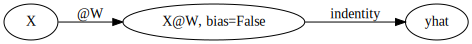

In [7]:
#collapse
gv('''
"X" -> "X@W, bias=False"[label="@W"] ;
"X@W, bias=False" -> "yhat"[label="indentity"] ''')

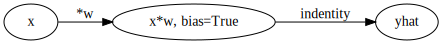

In [8]:
#collapse
gv('''
"x" -> "x*w, bias=True"[label="*w"] ;
"x*w, bias=True" -> "yhat"[label="indentity"] ''')

### 예제2: ploynomial regression 

$y_i = w_0 + w_1 x_i + w_2 x_i^2 + \epsilon_i$

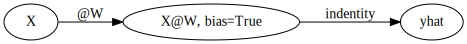

In [9]:
#collapse
gv('''
"X" -> "X@W, bias=True"[label="@W"]
"X@W, bias=True" -> "yhat"[label="indentity"] ''')

- ${\bf X}=\begin{bmatrix} x_1 & x_1^2 \\ \dots & \dots \\ x_n & x_n^2 \end{bmatrix}$ and ${\bf W}=\begin{bmatrix} w_0 \\ w_1 \end{bmatrix}$. 

#### 시뮬레이션 연습 

`-` 모형

In [10]:
torch.manual_seed(43052)
x,_=torch.randn(100).sort()
X= torch.vstack([x,x**2,x**3]).T
W=torch.tensor([[4.0],[3.0],[-2.0]])
bias=1.0
y=X@W + bias + torch.randn(100,1)

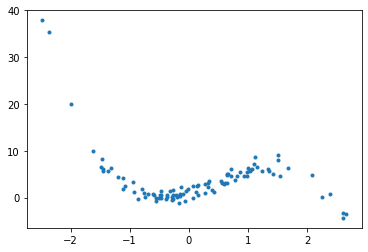

In [11]:
plt.plot(X[:,0],y,'.')

In [12]:
X.shape, W.shape, y.shape

(torch.Size([100, 3]), torch.Size([3, 1]), torch.Size([100, 1]))

- 입력차원 = 3
- 출력차원 = 1 
- bias = True

`-` 아키텍쳐 

In [13]:
net=torch.nn.Linear(in_features=3,out_features=1,bias=True)

`-` 손실함수 

In [14]:
loss_fn=torch.nn.MSELoss()

`-` 옵티마이저

In [15]:
optimizer=torch.optim.SGD(net.parameters(),lr=0.01) #lr =0.1 로 하면 잘터진다.. 

`-` step 1~4 반복 

In [16]:
for epoc in range(500):
    ## 1 
    yhat=net(X) 
    ## 2 
    loss=loss_fn(y,yhat)
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step()
    net.weight.grad = None

In [17]:
list(net.parameters())

[Parameter containing:
 tensor([[ 3.6145,  2.8557, -1.8802]], requires_grad=True),
 Parameter containing:
 tensor([1.0173], requires_grad=True)]

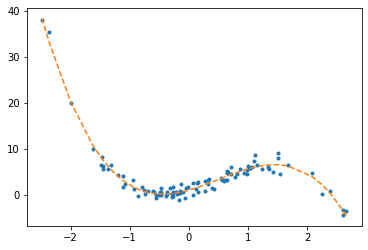

In [18]:
plt.plot(X[:,0],y,'.')
plt.plot(X[:,0],yhat.data,'--')

### 예제3: piece-wise linear regression 

`-` 모델

In [19]:
_x=np.linspace(-1,1,100).tolist()
_f=lambda x: x*1+np.random.normal()*0.3 if x<0 else x*3.5+np.random.normal()*0.3
_y=list(map(_f,_x))

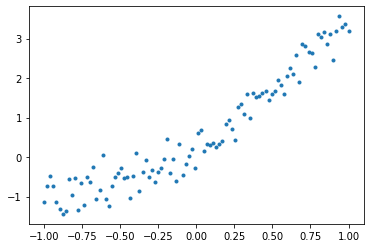

In [20]:
plt.plot(_x,_y,'.')

In [21]:
X=torch.tensor(_x).reshape(100,1)
y=torch.tensor(_y).reshape(100,1)

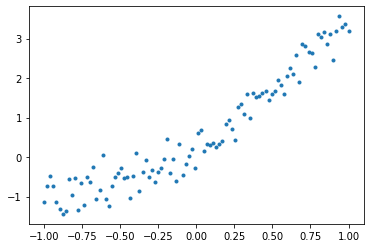

In [22]:
plt.plot(X,y,'.')

#### 풀이1

`-` 아키텍처 

In [23]:
net=torch.nn.Linear(in_features=1,out_features=1,bias=True)

`-` 손실함수 (MSE)

In [24]:
loss_fn = torch.nn.MSELoss()

`-` 옵티마이저 (SGD)

In [25]:
optimizer=torch.optim.SGD(net.parameters(),lr=0.1)

`-` step 1~4 반복 

In [26]:
for epoc in range(1000): 
    # 1 
    yhat=net(X.reshape(100,1))
    # 2 
    loss=loss_fn(yhat,y.reshape(100,1)) 
    # 3 
    loss.backward()
    # 4 
    optimizer.step()
    net.weight.grad = None

In [27]:
list(net.parameters())

[Parameter containing:
 tensor([[2.2849]], requires_grad=True),
 Parameter containing:
 tensor([0.4850], requires_grad=True)]

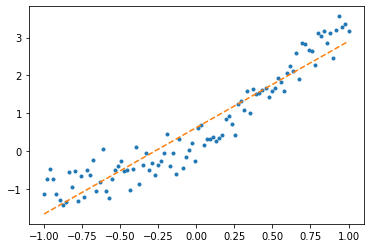

In [28]:
plt.plot(X,y,'.')
plt.plot(X,yhat.data,'--')

`-` 실패: 그리고 epoc을 10억번 반복해도 이건 못맞춤. 
- 왜? 모델자체가 틀렸음. 
- 모델의 표현력이 너무 부족하다. $\to$ underfitting 

#### 풀이2 (비선형 활성화함수 도입)

`-` 비선형함수를 추가하자. 

In [29]:
layer0=torch.nn.Linear(in_features=1,out_features=1,bias=False)
activation0=torch.nn.ReLU()
net2 = torch.nn.Sequential(layer0,activation0)
optimizer2=torch.optim.SGD(net2.parameters(),lr=0.1)

`-` 표현력 확인 

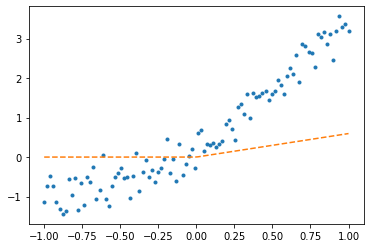

In [30]:
plt.plot(X,y,'.')
plt.plot(X,net2(X).data,'--')

`-` step 1~4

In [31]:
for epoc in range(1000): 
    # 1 
    yhat=net2(X.reshape(100,1))
    # 2 
    loss=loss_fn(yhat,y.reshape(100,1)) 
    # 3 
    loss.backward()
    # 4 
    optimizer2.step()
    net2.zero_grad()

`-` result 

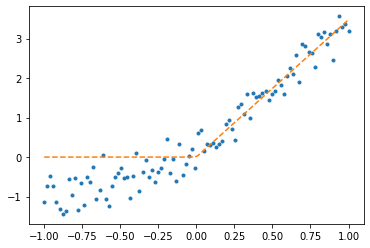

In [32]:
plt.plot(X,y,'.')
plt.plot(X,yhat.data,'--')

`-` discussion 
- 이것 역시 수백억번 epoc을 해봤자 이 이상은 적합시키기 힘들다 $\to$ 모형의 표현력이 너무 낮다. 
- 주황색선이 2개 있다면 어떨까?.. 

#### 풀이3 (넓은 신경망 + 비선형 활성화함수 도입)

`-` 아키텍처

In [33]:
torch.manual_seed(1) # 초기가중치를 똑같이.. 
layer1=torch.nn.Linear(in_features=1,out_features=2,bias=False)
activation1=torch.nn.ReLU()
layer2=torch.nn.Linear(in_features=2,out_features=1,bias=False)
net3 = torch.nn.Sequential(layer1,activation1,layer2)
optimizer3=torch.optim.SGD(net3.parameters(),lr=0.1)

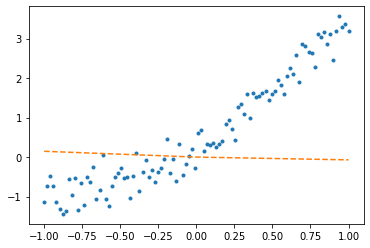

In [34]:
plt.plot(X,y,'.')
plt.plot(X,net3(X).data,'--')

`-` step 1~4 

In [35]:
for epoc in range(1000): 
    # 1 
    yhat=net3(X.reshape(100,1))
    # 2 
    loss=loss_fn(yhat,y.reshape(100,1)) 
    # 3 
    loss.backward()
    # 4 
    optimizer3.step()
    net3.zero_grad()

`-` result

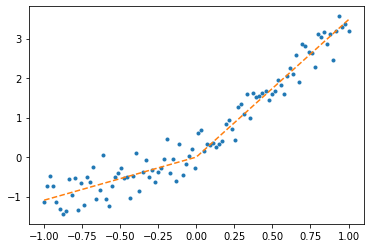

In [36]:
plt.plot(X,y,'.')
plt.plot(X,yhat.data,'--')

`-` discussion

In [37]:
list(net3.parameters())

[Parameter containing:
 tensor([[ 1.8915],
         [-1.0633]], requires_grad=True),
 Parameter containing:
 tensor([[ 1.8389, -1.0265]], requires_grad=True)]

- 파라메터 확인

In [38]:
W1=(layer1.weight.data).T
W2=(layer2.weight.data).T
W1,W2

(tensor([[ 1.8915, -1.0633]]),
 tensor([[ 1.8389],
         [-1.0265]]))

- 파라메터값을 저장

`-` 어떻게 적합이 이렇게 우수하게 되었는지 따져보자. 

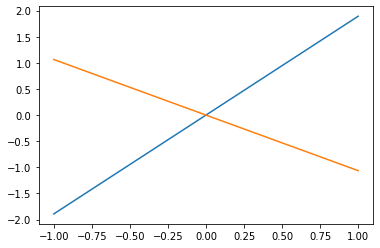

In [39]:
#plt.plot(X,X@W0)
u1=X@W1
plt.plot(X,u1) 

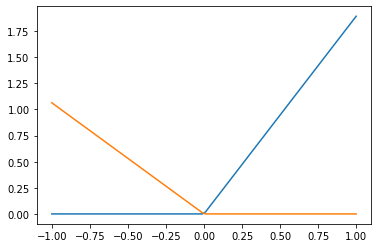

In [40]:
#plt.plot(X,activation0(X@W0))
v1=activation1(u1)
plt.plot(X,v1) 

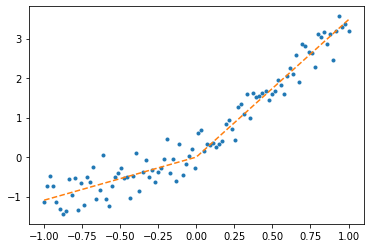

In [41]:
#plt.plot(X,activation0(X@W0)@W1) 
_yhat=v1@W2
plt.plot(X,y,'.')
plt.plot(X,_yhat,'--')

#### 잠깐요약 (넓은 신경망)

`-` 계산과정

(1) $X \to X@W^{(0)} \to ReLU(X@W^{(1)}) \to ReLU(X@W^{(0)})W^{(1)} = yhat $

- $X: n \times 1$
- $W^{(0)}: 1 \times 2$
- $W^{(1)}: 2 \times 1$

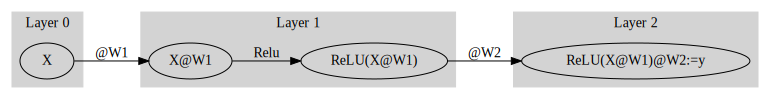

In [42]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "X" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "X" -> "X@W1"[label="@W1"]
    "X@W1" -> "ReLU(X@W1)"[label="Relu"]
    label = "Layer 1"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;
    "ReLU(X@W1)" -> "ReLU(X@W1)@W2:=y"[label="@W2"]
    label = "Layer 2"
}
''')

(2) 

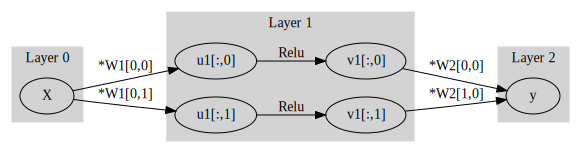

In [43]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "X" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "X" -> "u1[:,0]"[label="*W1[0,0]"]
    "X" -> "u1[:,1]"[label="*W1[0,1]"]
    "u1[:,0]" -> "v1[:,0]"[label="Relu"]
    "u1[:,1]" -> "v1[:,1]"[label="Relu"]
    label = "Layer 1"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;
    "v1[:,0]" -> "y"[label="*W2[0,0]"]
    "v1[:,1]" -> "y"[label="*W2[1,0]"]
    label = "Layer 2"
}
''')

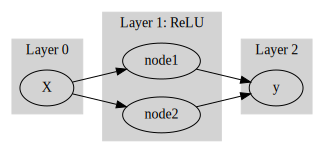

In [44]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "X" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "X" -> "node1"
    "X" -> "node2"
    label = "Layer 1: ReLU"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;
    "node1" -> "y"
    "node2" -> "y"
    label = "Layer 2"
}
''')

`-` 이러한 구조를 따라하면 예제1의 아키텍처는 아래와 같음 

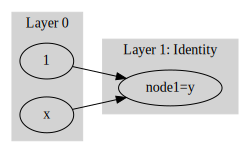

In [45]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "1" 
    "x" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "1" -> "node1=y"
    "x" -> "node1=y"
    label = "Layer 1: Identity"
}
''')

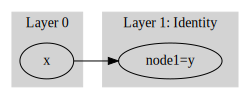

In [46]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "x" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "x" -> "node1=y"
    label = "Layer 1: Identity"
}
''')

`-` 예제2의 아키텍처

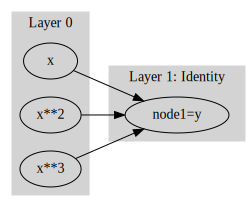

In [47]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "x" 
    "x**2" 
    "x**3" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "x" -> "node1=y"
    "x**2" -> "node1=y"
    "x**3" -> "node1=y"
    label = "Layer 1: Identity"
}
''')

#### 풀이3이 실패할수도 있음 (local minimum)

In [48]:
torch.manual_seed(40352) # 초기가중치를 똑같이.. 
layer0=torch.nn.Linear(in_features=1,out_features=2,bias=False)
activation0=torch.nn.ReLU()
layer1=torch.nn.Linear(in_features=2,out_features=1,bias=False)
net3 = torch.nn.Sequential(layer0,activation0,layer1)
optimizer3=torch.optim.SGD(net3.parameters(),lr=0.1)

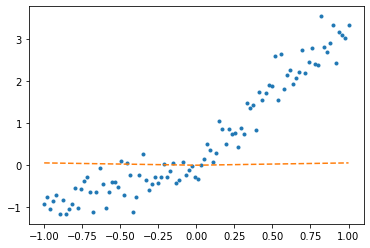

In [2134]:
plt.plot(X,y,'.')
plt.plot(X,net3(X).data,'--')

`-` step 1~4 

In [2135]:
for epoc in range(1000): 
    # 1 
    yhat=net3(X.reshape(100,1))
    # 2 
    loss=loss_fn(yhat,y.reshape(100,1)) 
    # 3 
    loss.backward()
    # 4 
    optimizer3.step()
    net3.zero_grad()

`-` result

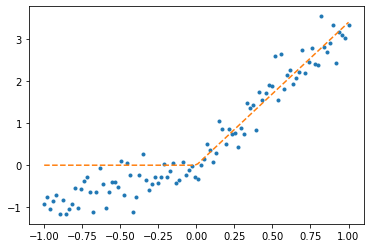

In [2136]:
plt.plot(X,y,'.')
plt.plot(X,yhat.data,'--')

`-` 가중치가 왜 안바뀔까? 

In [2137]:
W0=(layer0.weight.data).T
W1=(layer1.weight.data).T
W0,W1

(tensor([[7.1891e-04, 1.8046e+00]]),
 tensor([[0.0722],
         [1.8840]]))

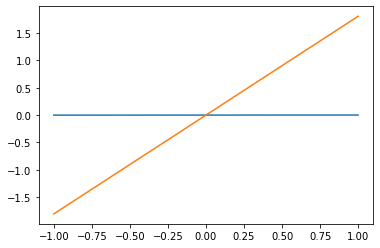

In [2138]:
#plt.plot(X,X@W0)
u0=X@W0
plt.plot(X,u0) 

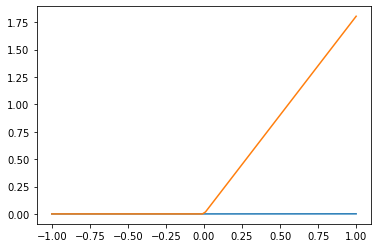

In [2139]:
#plt.plot(X,activation0(X@W0))
v0=activation0(u0)
plt.plot(X,v0) 

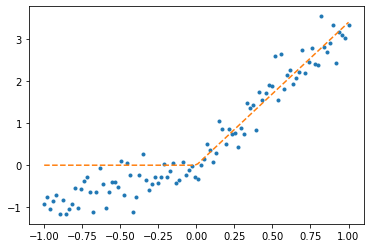

In [2140]:
#plt.plot(X,activation0(X@W0)@W1) 
_yhat=v0@W1
plt.plot(X,y,'.')
plt.plot(X,_yhat,'--')


`-` 고약한상황이 되었다.. 

#### 풀이4: 아주 넓은 신경망의 단점 

`-` 말이 안되는 소리에요.. 

`-` Custom Activation Function

In [2791]:
# simply define a silu function
# def mooyaho(input):
#     return torch.sigmoid((20*input)**5)*torch.sigmoid(-(20*input)**5)*4
    
def mooyaho(input):
    return torch.sigmoid(200*input)
    
class MOOYAHO(torch.nn.Module):
    def __init__(self):
        super().__init__() # init the base class

    def forward(self, input):
        return mooyaho(input) # simply apply already implemented SiLU

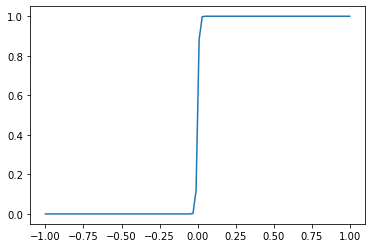

In [2792]:
x=torch.linspace(-1,1,100)
plt.plot(x,mooyaho(x))

`-` 아키텍처

In [2797]:
torch.manual_seed(1) # 초기가중치를 똑같이.. 
layer1=torch.nn.Linear(in_features=1,out_features=500,bias=True)
activation1=MOOYAHO()
layer2=torch.nn.Linear(in_features=500,out_features=1,bias=True)
net4 = torch.nn.Sequential(layer1,activation1,layer2)
optimizer4=torch.optim.SGD(net4.parameters(),lr=0.001)

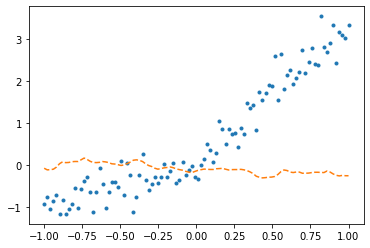

In [2798]:
plt.plot(X,y,'.')
plt.plot(X,net4(X).data,'--')

`-` step 1~4 

In [2799]:
for epoc in range(5000): 
    # 1 
    yhat=net4(X)
    # 2 
    loss=loss_fn(yhat,y) 
    # 3 
    loss.backward()
    # 4 
    optimizer4.step()
    net4.zero_grad()

`-` result

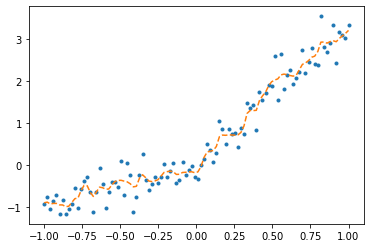

In [2800]:
plt.plot(X,y,'.')
plt.plot(X,yhat.data,'--')

`-` 넓은신경망은 과적합하기 딱 좋은 모델 

`-` 무엇이든 맞출 수 있음 

In [2801]:
torch.manual_seed(43052)
__X= torch.linspace(-1,1,100).reshape(100,1)
__y= torch.randn(100,1)

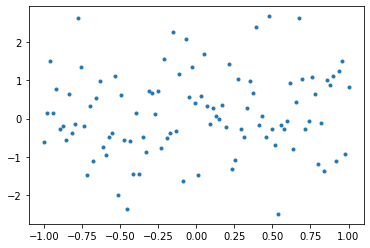

In [2802]:
plt.plot(__X,__y,'.')

`-` 아키텍쳐 

In [2803]:
torch.manual_seed(1) # 초기가중치를 똑같이.. 
layer1=torch.nn.Linear(in_features=1,out_features=1000,bias=True)
activation1=MOOYAHO() # activation1=torch.nn.ReLU() 
layer2=torch.nn.Linear(in_features=1000,out_features=1,bias=True)
net4 = torch.nn.Sequential(layer1,activation1,layer2)
optimizer4=torch.optim.SGD(net4.parameters(),lr=0.001)

`-` step 1~4 반복 

In [2804]:
for epoc in range(10000): 
    # 1 
    __yhat=net4(__X)
    # 2 
    loss=loss_fn(__yhat,__y) 
    # 3 
    loss.backward()
    # 4 
    optimizer4.step()
    net4.zero_grad()

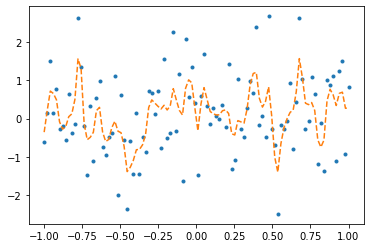

In [2805]:
plt.plot(__X,__y,'.')
plt.plot(__X,__yhat.data,'--')

In [2812]:
torch.mean((__y-0)**2),torch.mean((__y-__yhat.data)**2)

(tensor(1.1437), tensor(0.5297))